In [76]:
import numpy as np

# create random input data as 784 x 1 matrix
input_data = np.random.rand(784, 1)
input_data

array([[1.53582089e-01],
       [9.62842620e-01],
       [1.94520797e-01],
       [9.93682717e-01],
       [8.80070056e-01],
       [9.32937672e-01],
       [7.68003758e-01],
       [4.33151195e-01],
       [1.68558548e-01],
       [1.28179817e-01],
       [7.75670825e-01],
       [3.71135570e-01],
       [2.95546346e-01],
       [2.57153069e-01],
       [8.52856601e-01],
       [1.86095222e-01],
       [9.73046668e-01],
       [6.46479169e-01],
       [5.01113799e-01],
       [7.74680773e-01],
       [6.95918029e-01],
       [4.78632685e-01],
       [7.14598499e-02],
       [1.89100374e-01],
       [5.18015287e-01],
       [5.85709454e-01],
       [2.11524029e-01],
       [1.81468589e-01],
       [3.17859438e-02],
       [8.13730754e-01],
       [4.44674185e-01],
       [8.47723052e-01],
       [9.37589519e-01],
       [8.86085841e-01],
       [5.88621185e-01],
       [6.43331858e-01],
       [3.27319789e-01],
       [4.41457208e-01],
       [8.96700561e-02],
       [8.28912340e-01],


In [77]:
# create random weights as 784 x 1024 matrix
matrix_l1w = np.random.rand(784, 1024)

# create random weights as 1024 x 512 matrix for the second layer
matrix_l2w = np.random.rand(1024, 512)

# create random weights as 512 x 26 matrix for the output layer
matrix_l3w = np.random.rand(512, 26)

'''
o1 = np.dot(matrix_i, matrix_l1w)
print(o1)
so1 = sigmoid(o1)
o = np.dot(so1, matrix_ow)
so = sigmoid(o)
round(so[0][0], 3)
'''

# total weights of the network 1340416

ol1 = np.dot(input_data.T, matrix_l1w)
ol2 = np.dot(ol1, matrix_l2w)
o = np.dot(ol2, matrix_l3w)
o

array([[25857761.99861312, 25909867.32731565, 25570945.32345293,
        24904716.87248295, 25081696.38518851, 25328728.19336749,
        25355464.66662078, 25552594.72792408, 25145610.68357115,
        25862502.88218601, 25153667.28081635, 25387059.5072831 ,
        24752022.10943475, 24602558.02280166, 25797410.12356003,
        25236945.48708427, 25524220.35038517, 25157092.3791407 ,
        25013384.90300873, 26784280.58218826, 24845756.35934833,
        24631076.48391747, 24329022.95325897, 25119607.90889643,
        26406208.18710549, 25032423.85964377]])

In [78]:
o.dtype, 1340416 * 8 / 1024 / 1024 # bu sonuc bize kaç byte alana ihtiyaç olduğunu söyler. 1. 1024 kg, 2. 1024 mg verir.

(dtype('float64'), 10.2265625)

In [79]:
import kagglehub

# download latest version
path = kagglehub.dataset_download("datamunge/sign-language-mnist")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\MSI-NB\.cache\kagglehub\datasets\datamunge\sign-language-mnist\versions\1


In [80]:
%pip install plotly

Note: you may need to restart the kernel to use updated packages.


In [81]:
%pip install tensorflow

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import image_dataset_from_directory
from os import getcwd

In [83]:
import os

downloaded_files = os.listdir(path)
print(downloaded_files)

['american_sign_language.PNG', 'amer_sign2.png', 'amer_sign3.png', 'sign_mnist_test', 'sign_mnist_test.csv', 'sign_mnist_train', 'sign_mnist_train.csv']


In [84]:
# Eğitim ve test verilerini yükle

data_train = pd.read_csv(path + '/sign_mnist_train.csv')
data_test = pd.read_csv(path + '/sign_mnist_test.csv')

data_train

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27450,13,189,189,190,190,192,193,193,193,193,...,132,165,99,77,52,200,234,200,222,225
27451,23,151,154,157,158,160,161,163,164,166,...,198,198,198,198,198,196,195,195,195,194
27452,18,174,174,174,174,174,175,175,174,173,...,121,196,209,208,206,204,203,202,200,200
27453,17,177,181,184,185,187,189,190,191,191,...,119,56,27,58,102,79,47,64,87,93


In [85]:
# Eğitim verisi
training_images = data_train.iloc[:, 1:].values # Etiketler hariç tüm sütunlar
training_labels = data_train.iloc[:, 0].values # Etiketler

# Test verisi
testing_images = data_test.iloc[:, 1:].values
testing_labels = data_test.iloc[:, 0].values

training_images.shape

(27455, 784)

In [86]:
# Şekillendirme
training_images = training_images.reshape(-1, 28, 28, 1)  # Görüntü boyutları (n, 28, 28, 1)
testing_images = testing_images.reshape(-1, 28, 28, 1)  # Görüntü boyutları (n, 28, 28, 1)

training_images.shape

(27455, 28, 28, 1)

In [87]:
# Normalizasyon
training_images = training_images / 255.0
testing_images = testing_images / 255.0

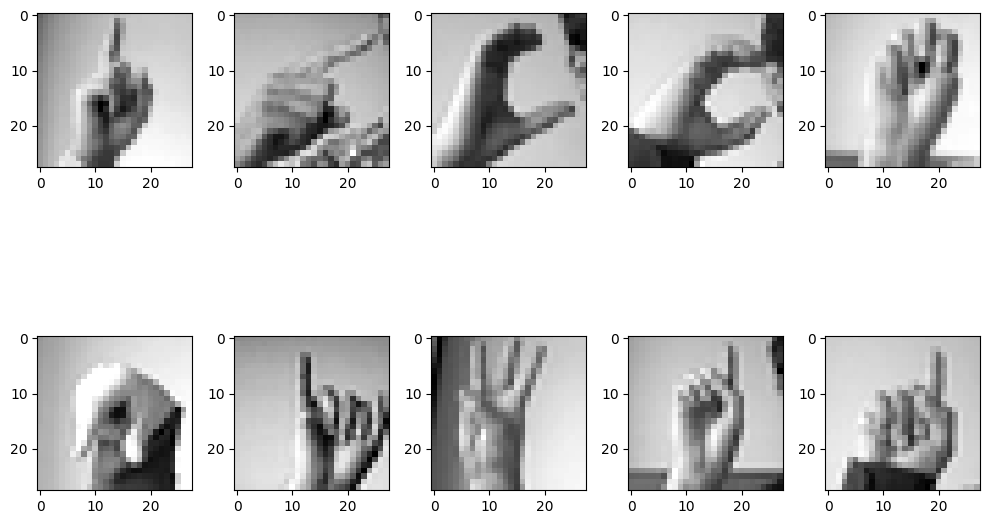

In [88]:
# İlk 10 görüntüyü görselleştirelim
fig, ax = plt.subplots(2, 5)
fig.set_size_inches(10, 10)
k = 0
for i in range(2):
    for j in range(5):
        ax[i, j].imshow(training_images[k].reshape(28, 28), cmap = 'gray')
        k += 1
    plt.tight_layout()

In [89]:
# Veri artırma işlemleri (Training Data için)
# Eğitim için veri artırma (augmentation) işlemi
train_datagen = ImageDataGenerator(
    rescale=1./255,  # Görüntüleri 0-1 aralığına çekme
    rotation_range=40,  # 40 dereceye kadar dönüş
    width_shift_range=0.2,  # Yatayda kaydırma
    height_shift_range=0.2,  # Dikeyde kaydırma
    shear_range=0.2,  # Kesme
    zoom_range=0.2,  # Yakınlaştırma
    horizontal_flip=True,  # Yatayda çevirme
    fill_mode='nearest'  # Boşlukları doldurma
)

In [90]:
# Doğal test veri ön işleme (Validation Data için)
validation_datagen = ImageDataGenerator(
    rescale=1/255
)

In [91]:
# Model oluşturma
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(26, activation='softmax')
])

c:\Users\MSI-NB\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [92]:
# Model derlemesi
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [93]:
# Hata mesajını daha ayrıntılı görmek için:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)  # TensorFlow sürümünü kontrol edelim

TensorFlow version: 2.18.0


In [94]:
# Modeli eğitme
history = model.fit(
    train_datagen.flow(training_images, training_labels, batch_size=32),  # Eğitim verileri
    steps_per_epoch=len(training_images) // 32,  # Her epoch'ta adım sayısı
    epochs=10,  # Eğitim sayısı
    validation_data=validation_datagen.flow(testing_images, testing_labels, batch_size=32),  # Doğrulama verileri
    validation_steps=len(testing_images) // 32  # Doğrulama adım sayısı
)

Epoch 1/10


c:\Users\MSI-NB\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


857/857 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.0430 - loss: 3.1973 - val_accuracy: 0.0287 - val_loss: 3.2038
Epoch 2/10
  1/857 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.0625 - loss: 3.1811

c:\Users\MSI-NB\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


857/857 ━━━━━━━━━━━━━━━━━━━━ 1s 663us/step - accuracy: 0.0625 - loss: 3.1811 - val_accuracy: 0.0287 - val_loss: 3.2031
Epoch 3/10
857/857 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.0472 - loss: 3.1792 - val_accuracy: 0.0201 - val_loss: 3.1969
Epoch 4/10
857/857 ━━━━━━━━━━━━━━━━━━━━ 1s 694us/step - accuracy: 0.0312 - loss: 3.1703 - val_accuracy: 0.0201 - val_loss: 3.1970
Epoch 5/10
857/857 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.0440 - loss: 3.1786 - val_accuracy: 0.0201 - val_loss: 3.2028
Epoch 6/10
857/857 ━━━━━━━━━━━━━━━━━━━━ 1s 636us/step - accuracy: 0.1250 - loss: 3.1712 - val_accuracy: 0.0201 - val_loss: 3.2031
Epoch 7/10
857/857 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.0471 - loss: 3.1774 - val_accuracy: 0.0229 - val_loss: 3.1961
Epoch 8/10
857/857 ━━━━━━━━━━━━━━━━━━━━ 1s 608us/step - accuracy: 0.0938 - loss: 3.1678 - val_accuracy: 0.0229 - val_loss: 3.1959
Epoch 9/10
857/857 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.0413 - loss: 3.1777 - val_accurac

In [95]:
# save model
model.save("sign_language_model.keras")

In [96]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │       410,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 26)             │        13,338 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,299,056 (4.96 MB)

 Trainable params: 433,018 (1.65 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 866,038 (3.30 MB)

In [97]:
model2 = tf.keras.models.load_model("sign_language_model.keras")
model2.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │       410,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 26)             │        13,338 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,299,056 (4.96 MB)

 Trainable params: 433,018 (1.65 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 866,038 (3.30 MB)

In [98]:
model2.evaluate(testing_images, testing_labels)

225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0140 - loss: 3.7165


[3.7116706371307373, 0.014221974648535252]

In [99]:
model2.predict([testing_images[0].reshape(1, 28, 28,  1)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


c:\Users\MSI-NB\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_3
Received: inputs=('Tensor(shape=(1, 28, 28, 1))',)
  warnings.warn(msg)


array([[2.4968853e-02, 1.2652137e-02, 4.0758740e-02, 8.4501155e-02,
        1.0551564e-02, 3.0185832e-02, 8.8090925e-03, 1.3590765e-02,
        3.8334690e-02, 2.8044828e-26, 2.5480678e-02, 9.1964580e-02,
        1.8696496e-02, 4.9272530e-02, 3.5587467e-02, 1.3655888e-02,
        9.9216938e-02, 9.7827733e-02, 7.5862668e-02, 4.8799351e-02,
        4.2045977e-02, 3.2803960e-02, 3.0184004e-02, 3.5254609e-02,
        3.8994256e-02, 2.1126507e-26]], dtype=float32)